# 01 — Muncie: end-to-end read & visualize

**Goal.** Open the HEC-RAS Muncie 2D project, pull every mesh artefact we will eventually want as a *label* for Phase A / Phase B (cells, breaklines, refinement regions, perimeter, computation points), pull the *input* the model will eventually predict from (the terrain DEM), and plot them all together so we can *see* that they line up.

This is the "data pipeline is real" milestone for the make-one-work sprint. If this notebook executes top-to-bottom without errors and the final figure looks sensible, we have validated the read side of the pipeline.

**Notes for future-Dante.** The Muncie HEC-RAS HDF does *not* embed a CRS (`g.projection()` returns `None`). The CRS lives on the terrain TIFF instead, and we have to manually assign it to the geometry layers after loading. This is a quirk of older HEC-RAS projects; newer ones include CRS in the HDF. Be ready to handle both at scale.

## 1. Imports

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from matplotlib.colors import LightSource
from rashdf import RasGeomHdf

## 2. Paths

In [2]:
REPO_ROOT = Path.cwd().parent  # notebook lives in notebooks/, repo is one level up
MUNCIE_DIR = (
    REPO_ROOT
    / "data"
    / "raw"
    / "usace"
    / "RAS Samples"
    / "Example_Projects_7_0"
    / "2D Unsteady Flow Hydraulics"
    / "Muncie"
)

GEOM_HDF = MUNCIE_DIR / "Muncie.g04.hdf"
TERRAIN_VRT = MUNCIE_DIR / "Terrain" / "Terrain.vrt"
TERRAIN_TIF = MUNCIE_DIR / "Terrain" / "Terrain.muncie_clip.tif"
TERRAIN = TERRAIN_VRT if TERRAIN_VRT.exists() else TERRAIN_TIF

assert GEOM_HDF.exists(), f"missing: {GEOM_HDF}"
assert TERRAIN.exists(), f"missing terrain: {TERRAIN}"

print(f"geometry HDF : {GEOM_HDF.name}  ({GEOM_HDF.stat().st_size / 1024:.0f} KB)")
print(f"terrain      : {TERRAIN.relative_to(MUNCIE_DIR)}")

geometry HDF : Muncie.g04.hdf  (532 KB)
terrain      : Terrain\Terrain.vrt


## 3. Load the terrain raster — and capture the CRS

> **Primer — what a DEM is.** Digital Elevation Model = a raster (2D grid of pixels) where each pixel value is the ground elevation at that location. Continuous, not categorical. For Muncie, the DEM is a `Terrain.vrt` virtual raster wrapping an underlying `.tif`. `rasterio` reads either transparently.

> **Primer — why CRS matters.** A Coordinate Reference System defines how (x, y) numbers in a geometry map to a real location on Earth. Two layers with the same x/y values can describe completely different places if their CRS differs. Before overlaying anything, all layers must be in the same CRS — otherwise the plot looks fine but the geometry is wrong.

We load the terrain *first* because in older HEC-RAS projects (like this one) the CRS is stored on the terrain raster, not in the geometry HDF. Once we have it, we'll assign it to the mesh GeoDataFrames as we load them.

In [3]:
with rasterio.open(TERRAIN) as src:
    print(f"terrain CRS    : {src.crs}")
    print(f"  EPSG code    : {src.crs.to_epsg()}")
    print(f"  linear units : {src.crs.linear_units}")
    print(f"terrain bounds : {tuple(round(b, 1) for b in src.bounds)}")
    print(f"terrain shape  : {src.height} rows × {src.width} cols  ({src.height * src.width / 1e6:.1f} Mpx)")
    print(f"resolution     : {src.res} (units of CRS)")
    print(f"nodata         : {src.nodata}")
    print(f"dtype          : {src.dtypes[0]}")

    PROJECT_CRS = src.crs
    dem = src.read(1, masked=True)
    terrain_bounds = src.bounds

print(f"\nDEM elevation range: {dem.min():.1f} → {dem.max():.1f} (US survey feet, NAVD88 likely)")

terrain CRS    : EPSG:2965
  EPSG code    : 2965
  linear units : US survey foot
terrain bounds : (384977.8, 1788863.5, 424437.8, 1811553.5)
terrain shape  : 4538 rows × 7892 cols  (35.8 Mpx)
resolution     : (5.0, 5.0) (units of CRS)
nodata         : -9999.0
dtype          : float32



DEM elevation range: 898.9 → 1013.2 (US survey feet, NAVD88 likely)


## 4. Open the geometry HDF and load every mesh element

> **Primer — what `rashdf` does.** A HEC-RAS `.gNN.hdf` file is a binary HDF5 file: hierarchical, like a filesystem inside a single file. Inside are groups for the 2D mesh, breaklines, refinement regions, computation points, hydraulic property tables, etc. `rashdf` knows the layout and exposes those groups as friendly Python objects — mostly `GeoDataFrame`s (geopandas DataFrames with a `geometry` column of shapely shapes).

For Phase A (breakline detection) we care about: **breaklines** (the labels), **mesh_cell_polygons** (what the breaklines snap to), **mesh_areas** (the 2D flow area perimeter = the region we're allowed to predict inside).

For Phase B (resolution field) we also care about: **refinement_regions** (polygons that change local cell size), **mesh_cell_points** (the computation points = Delaunay vertices).

We load all five so the same notebook is the reference for both phases. After loading, we manually assign `PROJECT_CRS` to each layer because this older HEC-RAS HDF doesn't embed one.

In [4]:
g = RasGeomHdf.open_uri(str(GEOM_HDF))

print("projection embedded in HDF:", g.projection() or "(none — using terrain CRS)")
print("2D mesh area names in this project:")
for name in g.mesh_area_names():
    print(f"  - {name}")

projection embedded in HDF: (none — using terrain CRS)
2D mesh area names in this project:
  - 2D Interior Area


In [5]:
def _assign_crs(gdf, crs):
    """Set the CRS if it's a non-empty GeoDataFrame with a geometry column."""
    if gdf is None or len(gdf) == 0 or "geometry" not in gdf.columns:
        return gdf
    return gdf.set_crs(crs, allow_override=True)


cells = _assign_crs(g.mesh_cell_polygons(), PROJECT_CRS)
points = _assign_crs(g.mesh_cell_points(), PROJECT_CRS)
areas = _assign_crs(g.mesh_areas(), PROJECT_CRS)
breaklines = _assign_crs(g.breaklines(), PROJECT_CRS)
refinement = _assign_crs(g.refinement_regions(), PROJECT_CRS)

layers = {
    "mesh_cell_polygons": cells,
    "mesh_cell_points": points,
    "mesh_areas (perimeter)": areas,
    "breaklines": breaklines,
    "refinement_regions": refinement,
}

print(f"{'layer':<28} {'count':>6}  {'geom_type':<15}  {'crs':<22}")
print("-" * 80)
for name, gdf in layers.items():
    if gdf is None or len(gdf) == 0 or "geometry" not in gdf.columns:
        print(f"{name:<28} {'EMPTY':>6}")
        continue
    crs_short = (gdf.crs.name if gdf.crs else "(none)")[:22]
    print(f"{name:<28} {len(gdf):>6}  {gdf.geom_type.iloc[0]:<15}  {crs_short:<22}")

layer                         count  geom_type        crs                   
--------------------------------------------------------------------------------
mesh_cell_polygons             5391  Polygon          NAD83 / Indiana East (
mesh_cell_points               5391  Point            NAD83 / Indiana East (
mesh_areas (perimeter)            1  Polygon          NAD83 / Indiana East (
breaklines                        2  LineString       NAD83 / Indiana East (
refinement_regions            EMPTY


Peek inside the layers we'll lean on most:

In [6]:
print("mesh_cell_polygons columns:", list(cells.columns))
cells.head(3)

mesh_cell_polygons columns: ['mesh_name', 'cell_id', 'geometry']


,mesh_name,cell_id,geometry
0,2D Interior Area,0,"POLYGON ((406025 1805015.237, 406025 1804975, ..."
1,2D Interior Area,1,"POLYGON ((406075 1805018.545, 406075 1804975, ..."
2,2D Interior Area,2,"POLYGON ((406075 1804975, 406075 1805018.545, ..."


In [7]:
print("breaklines columns:", list(breaklines.columns))
breaklines

breaklines columns: ['bl_id', 'name', 'geometry']


,bl_id,name,geometry
0,0,Road 1,"LINESTRING (409074.779 1802876.359, 409026.142..."
1,1,HighGround 1,"LINESTRING (410305.8 1801586.638, 410290.706 1..."


## 5. Spatial sanity check

All non-empty geometry layers should share the same CRS now (we just assigned it). The more meaningful check is whether the mesh actually fits *inside* the terrain extent — if the mesh hangs off the edge, the DEM clip is too tight and we'll have NaNs at training time.

In [8]:
# All layers with geometry should share the project CRS
crss = {name: gdf.crs for name, gdf in layers.items() if gdf is not None and len(gdf) > 0 and "geometry" in gdf.columns}
unique_crss = {str(crs) for crs in crss.values()}
assert len(unique_crss) == 1, f"CRS mismatch across layers: {crss}"
print(f"All non-empty geometry layers share CRS: {next(iter(crss.values())).name}")

# Mesh extent vs terrain extent
mesh_bounds = areas.total_bounds  # [minx, miny, maxx, maxy]
tb = terrain_bounds
print("\nextent comparison (project CRS units):")
print(f"  terrain : x [{tb.left:>12.1f}  {tb.right:>12.1f}]   y [{tb.bottom:>12.1f}  {tb.top:>12.1f}]")
print(f"  mesh    : x [{mesh_bounds[0]:>12.1f}  {mesh_bounds[2]:>12.1f}]   y [{mesh_bounds[1]:>12.1f}  {mesh_bounds[3]:>12.1f}]")

assert (
    mesh_bounds[0] >= tb.left
    and mesh_bounds[1] >= tb.bottom
    and mesh_bounds[2] <= tb.right
    and mesh_bounds[3] <= tb.top
), "mesh extends outside the terrain raster — DEM clip is too tight"
print("\nMesh is fully inside the terrain extent.")

All non-empty geometry layers share CRS: NAD83 / Indiana East (ftUS)

extent comparison (project CRS units):
  terrain : x [    384977.8      424437.8]   y [   1788863.5     1811553.5]
  mesh    : x [    404980.1      412236.6]   y [   1801018.7     1805022.8]

Mesh is fully inside the terrain extent.


## 6. Overlay plot — everything on one figure

Layers, from bottom to top:

- **Terrain** as hillshade-blended elevation colormap (background)
- **Mesh cells** as very thin gray polygons
- **2D flow area perimeter** as bold black outline
- **Refinement regions** (if any) as yellow translucent fill
- **Breaklines** in red — these should follow ridges / embankments visible in the terrain
- **Computation points** as small cyan dots — these are the Delaunay vertices the mesh is built around

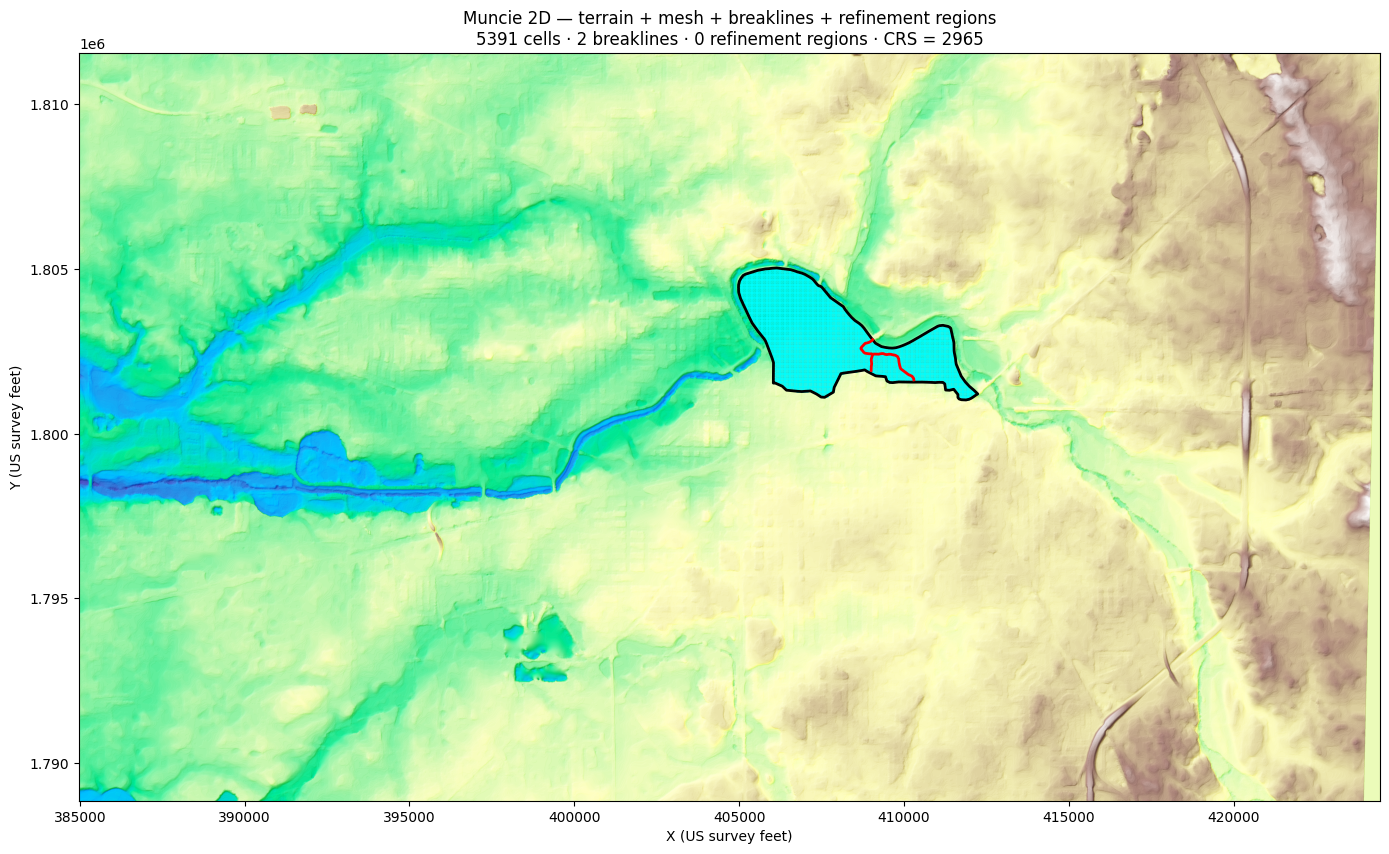

In [9]:
fig, ax = plt.subplots(figsize=(14, 11))

# Terrain: hillshade-blended elevation colormap
ls = LightSource(azdeg=315, altdeg=45)
shaded = ls.shade(
    dem.filled(float(dem.mean())),
    cmap=plt.cm.terrain,
    vert_exag=2,
    blend_mode="soft",
)
ax.imshow(
    shaded,
    extent=[terrain_bounds.left, terrain_bounds.right, terrain_bounds.bottom, terrain_bounds.top],
    origin="upper",
)

# Mesh cells: very thin polygons
cells.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.15, alpha=0.5)

# 2D flow area perimeter
areas.boundary.plot(ax=ax, color="black", linewidth=2.0)

# Refinement regions (if present)
if refinement is not None and len(refinement) > 0:
    refinement.plot(ax=ax, facecolor="yellow", edgecolor="orange", alpha=0.25, linewidth=1.0)

# Breaklines
if breaklines is not None and len(breaklines) > 0:
    breaklines.plot(ax=ax, color="red", linewidth=2.0)

# Computation points
if points is not None and len(points) > 0:
    points.plot(ax=ax, color="cyan", markersize=1.5, alpha=0.5)

ax.set_title(
    f"Muncie 2D — terrain + mesh + breaklines + refinement regions\n"
    f"{len(cells)} cells · {len(breaklines)} breaklines · {len(refinement)} refinement regions · CRS = {PROJECT_CRS.to_epsg()}"
)
ax.set_xlabel("X (US survey feet)")
ax.set_ylabel("Y (US survey feet)")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 7. Retro

**What we verified.**

- `rashdf` opens `.g04.hdf` and gives back GeoDataFrames for every mesh artefact we need.
- The Muncie HDF does *not* embed a CRS — we sourced it from the terrain TIFF (EPSG:2965, NAD83 Indiana East ftUS) and assigned it to the layers manually. The pipeline at scale will need to handle both "CRS in HDF" and "CRS in terrain only".
- The 2D flow area perimeter, mesh cells, and computation points are coherent on the terrain.
- Muncie has **2 breaklines and 0 refinement regions**. This is fine for plumbing but not a meaningful training signal — Muncie's role is just to validate the read path, not to teach the model anything.

**Things to watch when we scale to bulk FEMA.**

- Each FEMA study has its own CRS. Our pipeline must reproject (or sample in a common projection) before stacking features.
- Many FEMA studies have empty breaklines / refinement regions. Our quality filter must detect those and either reject or annotate them.
- Terrain at scale arrives as multi-tile mosaics — windowed reads, not load-everything-in-memory.
- Some HEC-RAS HDFs (newer ones) *do* embed CRS via `g.projection()`. The loader should prefer that and fall back to the terrain only when missing.

**Next (Week 2 — Features & labels).**

- Build DEM derivative functions (slope, aspect, plan/profile curvature, TWI, flow accumulation) that consume the rasterio array we loaded above.
- Build a breakline rasterizer that turns the `breaklines` GeoDataFrame into a binary label raster aligned to the DEM grid.
- Build a TorchGeo-compatible dataset over Muncie + Bald Eagle so we can train on tiles.